### Build a basic Chatbot with Langgraph(GRAPH API)

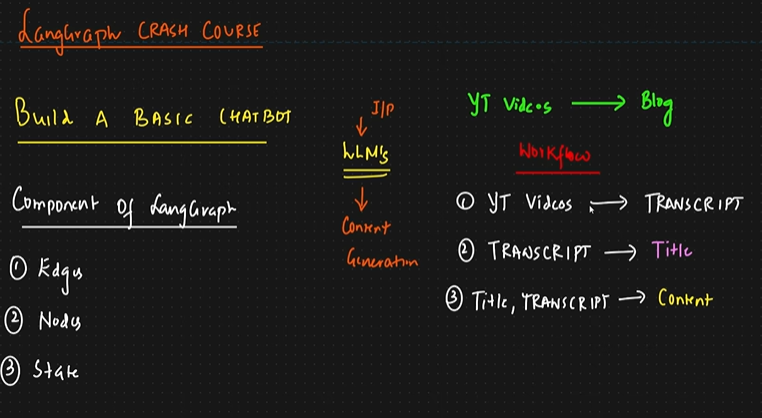

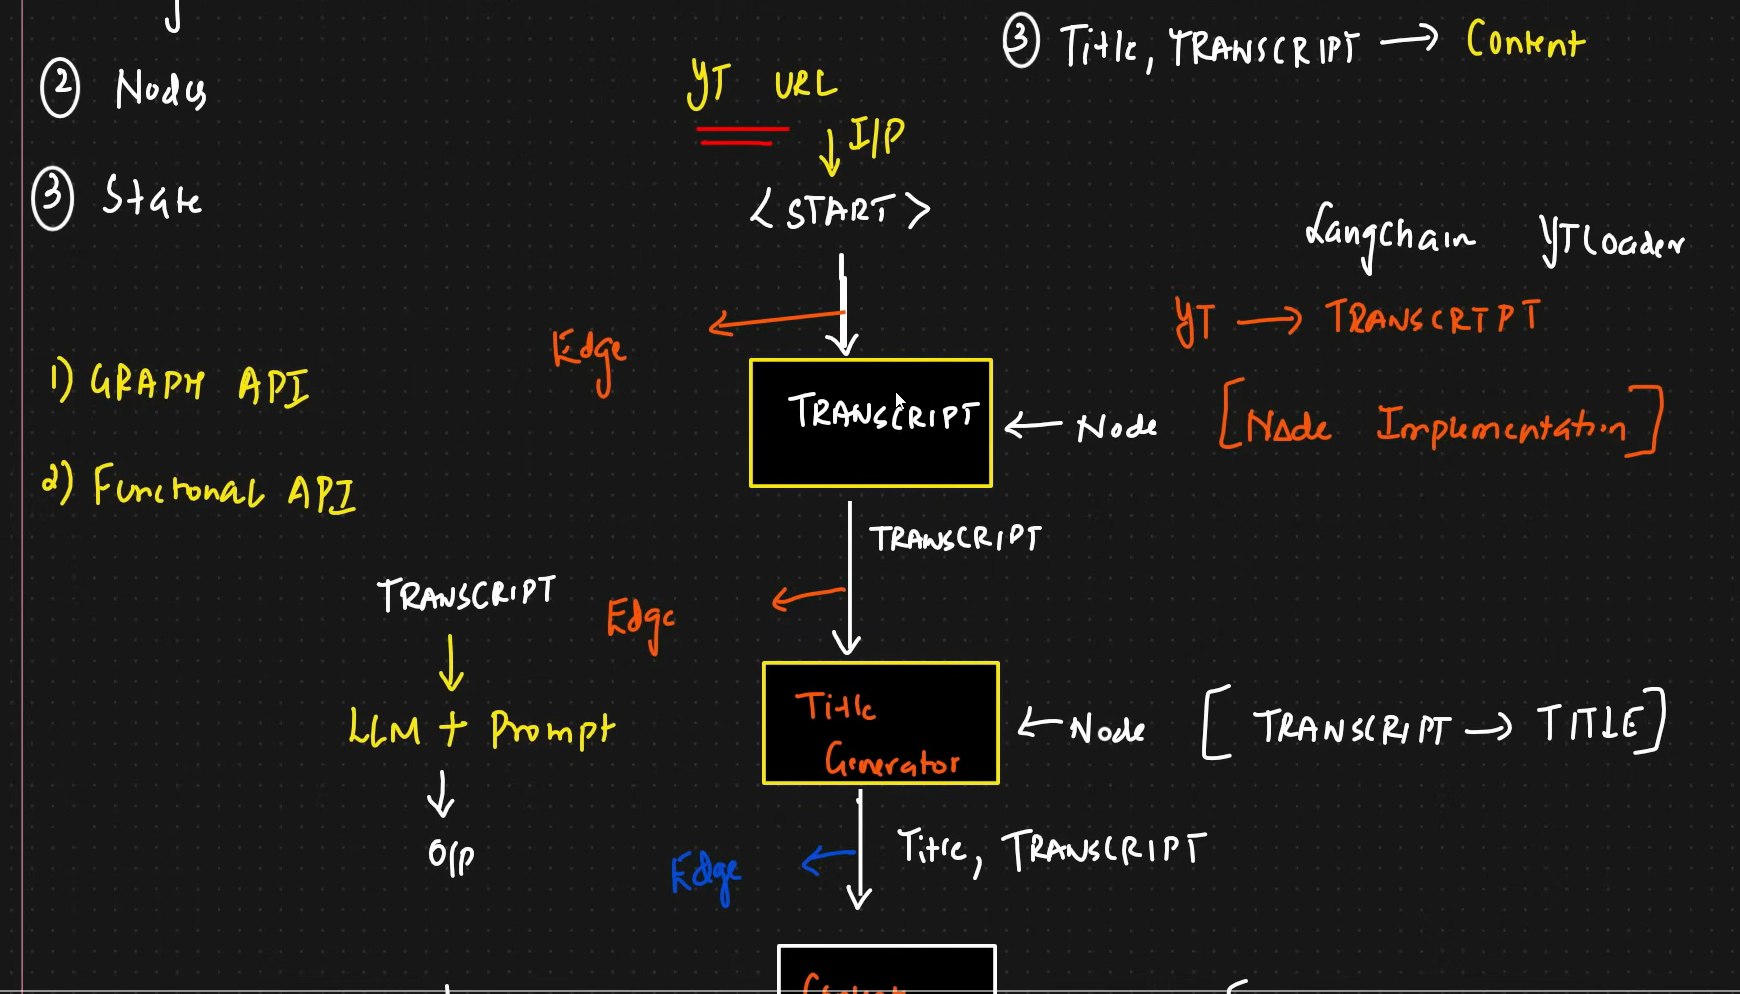

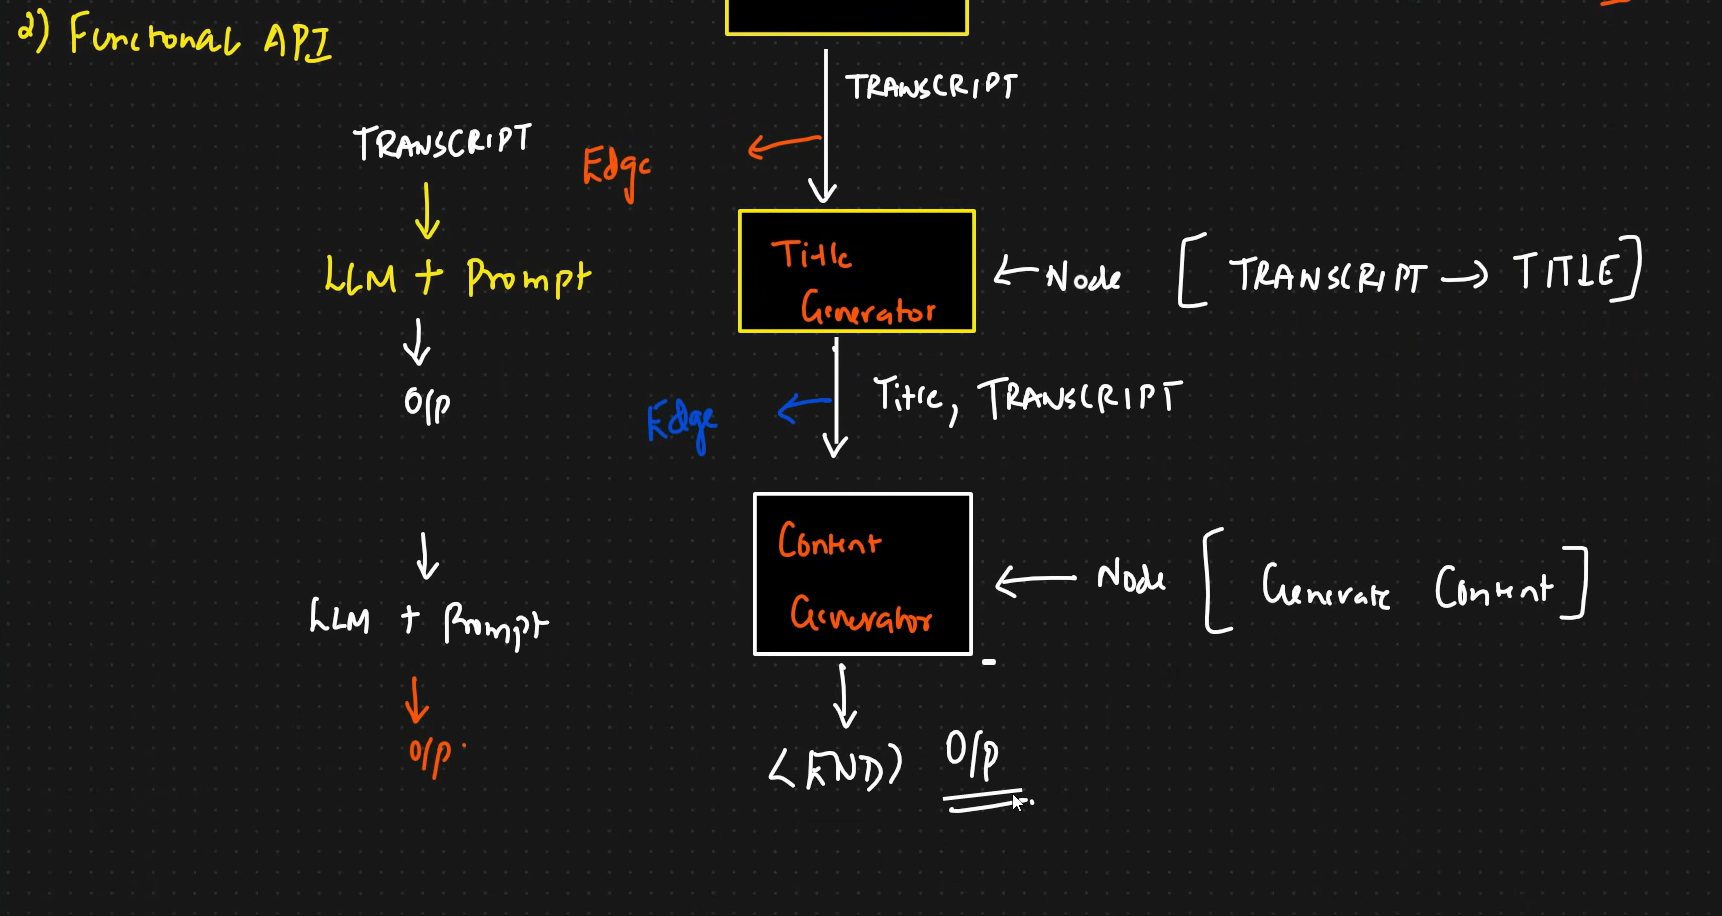

Node and edge we covered but what about state?

we define variables in state which contains the information maintained which can be accessed by every nodes. This is the advantage of storing them. 
EX- Transcipts, Title, Content


ANd this ENtire graph above is known as STateGraph as it is able to maintain the context of the state ata every node.

State {
    Transcript:" "
    Title: ""
    Content: ""
}

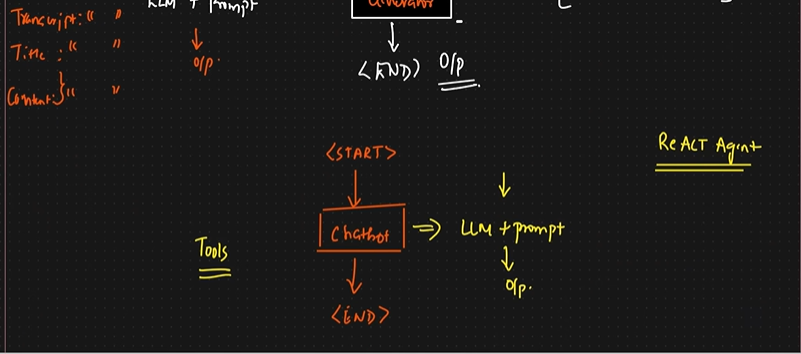

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


add_messages are called as reducers, the importance of reducers
- to create above chatbot, we ahve a state. In this state what is the kind of variable that can be created so all the output generated by chatbot will be saved in one variable itself?
- we can create messages of list type which gets appended evrytime we have a conversation with chatbot. and it will be available to node at any point of time 
- in order to append it we can use reducers  for example add_messages
- its task is onlly to add messages in any variable we define

In [2]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "openai/gpt-oss-120b")
 


In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020FB00E5550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020FB00E6270>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model("google_genai:gemini-3.5-flash-lite")
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.5 Flash Lite', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.5-flash-lite', temperature=None, client=<google.genai.client.Client object at 0x0000020FB1D99FD0>, default_metadata=(), model_kwar

In [8]:
## Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

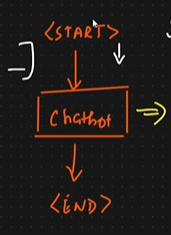

In [9]:
graph_builder = StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## COmpile Graph
graph = graph_builder.compile()


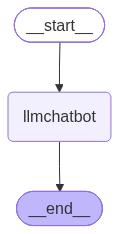

In [10]:
## visulise the graph

from IPython.display import Image,display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({"messages":"Hi"})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [12]:
response['messages'][-1].content

[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'El4KXAERTTIPeFNskItfB21kF/axDZABlFvBR4zwYbXBwLs8oATD29DdaaUHmaOy0SmabuEV7Y1CDIjhZ+QMZc38U0bHm2cTdPoi7zzgJDNxvK88/lgAPbcPoVNd4nwv'}}]

In [13]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

[{'type': 'text', 'text': "Hi! I'm doing well, thank you for asking. How can I help you today?", 'extras': {'signature': 'El4KXAERTTIP8M+p4Rh5+8e/ygLFDnsZeazpDJ4NhtIA+WEicfZU8nPmb+epQ8RMmYGdAxj8XJebodcLuhufS3t7Q74CIxLzoo3GHZpbf+IGtpJL97BnYGlDAlmDlgdu'}}]


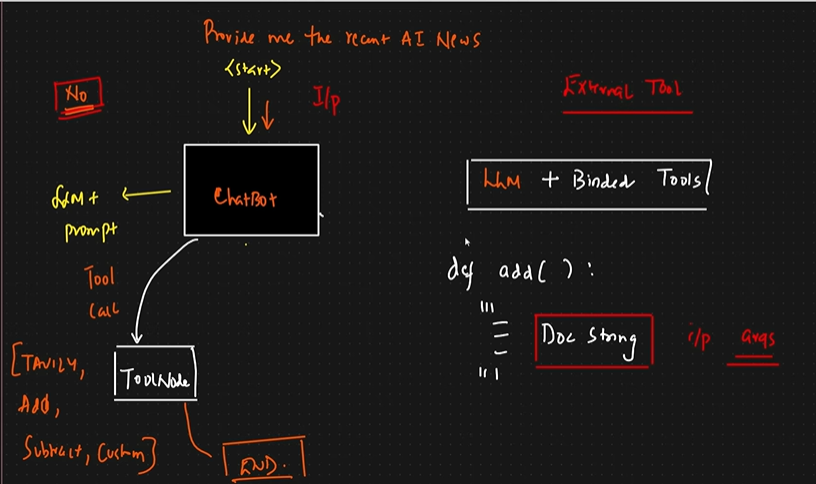

### CHatbot with TOol

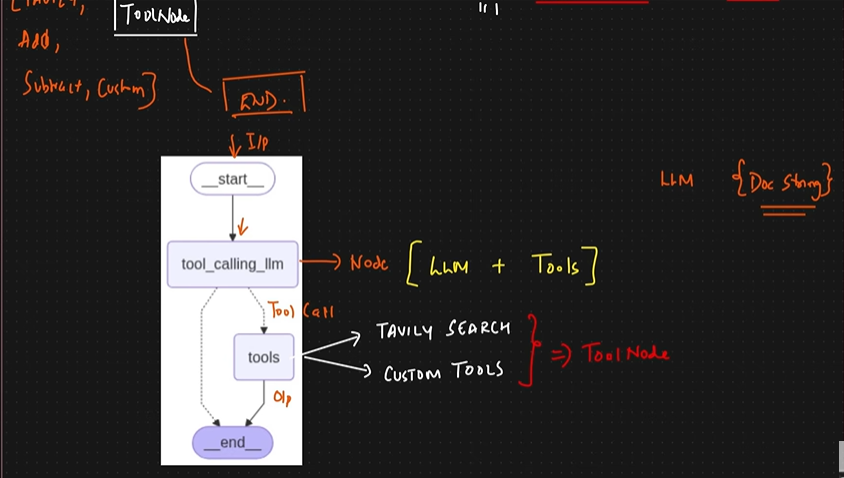

In [14]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results = 2)
tavily_tool.invoke("WHat is RAG?")

{'query': 'WHat is RAG?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/retrieval-augmented-generation',
   'title': 'What is RAG? - Retrieval-Augmented Generation AI Explained - AWS',
   'content': "Retrieval-Augmented Generation (RAG) is the process of optimizing the output of a large language model, so it references an authoritative knowledge base outside of its training data sources before generating a response. Large Language Models (LLMs) are trained on vast volumes of data and use billions of parameters to generate original output for tasks like answering questions, translating languages, and completing sentences. RAG extends the already powerful capabilities of LLMs to specific [...] RAG is one approach to solving some of these challenges. It redirects the LLM to retrieve relevant information from authoritative, pre-determined knowledge sources. Organizations have greater control over the generated text output

In [15]:
### Custom Function

def multiply(a:int,b:int)->int:
    """ Multiply a and b

    Args:
        a (int): first no
        b (int): second no

    returns:
        int: ouput int 
    """
    return(a*b)

In [16]:
tools = [tavily_tool,multiply]

In [17]:
llm_with_tool = llm.bind_tools(tools)

In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.5 Flash Lite', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.5-flash-lite', temperature=None, client=<google.genai.client.Client object at 0x0000020FB1D99FD0>, default

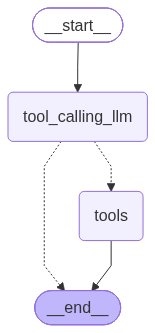

In [19]:
# Stategraph
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

#Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages":"Who won the recent spanish grand Prix? Give me Name of the driver and race date"})

In [28]:
response['messages'][-1].content

'{"query": "Spanish Grand Prix recent winner driver race date", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.formula1.com/en/latest/article/antonelli-clinches-victory-over-verstappen-and-norris-in-spanish-gp.644ZZfPzRPEaUh2JBHcB9", "title": "2026 Spanish Grand Prix race report and highlights: Kimi Antonelli clinches victory over Max Verstappen and Lando Norris in Spanish Grand Prix", "content": "MADRID, SPAIN - SEPTEMBER 13: Race winner Andrea Kimi Antonelli of Italy and Mercedes AMG Petronas/GettyImages-2295054259.webp)\\n\\nKimi Antonelli has boosted his title ambitions with victory in the Spanish Grand Prix, the Mercedes driver edging out Red Bull’s Max Verstappen and McLaren’s Lando Norris in a race swayed by strategy. [...] MADRID, SPAIN - SEPTEMBER 12: Race winner Pedro Clerot of Brazil and Rodin Motorsport (17)F3: Clerot seals win in Madrid as Campos take Teams’ title [...] MADRID, SPAIN - SEPTEMBER 12: Seventeenth placed qualifier 

In [29]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Who won the recent spanish grand Prix? Give me Name of the driver and race date
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (call_132845)
 Call ID: call_132845
  Args:
    query: Spanish Grand Prix recent winner driver race date
================================= Tool Message =================================
Name: tavily_search

{"query": "Spanish Grand Prix recent winner driver race date", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.formula1.com/en/latest/article/antonelli-clinches-victory-over-verstappen-and-norris-in-spanish-gp.644ZZfPzRPEaUh2JBHcB9", "title": "2026 Spanish Grand Prix race report and highlights: Kimi Antonelli clinches victory over Max Verstappen and Lando Norris in Spanish Grand Prix", "content": "MADRID, SPAIN - SEPTEMBER 13: Race winner Andrea Kimi Antonelli of Italy 

In [34]:
response = graph.invoke({"messages":"What is 5 into 10?"})

In [35]:
response

{'messages': [HumanMessage(content='What is 5 into 10?', additional_kwargs={}, response_metadata={}, id='53f421d6-b8bb-4d13-9650-791aade8ae61'),
  AIMessage(content=[{'type': 'text', 'text': '5 divided into 10 is **2** (since $10 \\div 5 = 2$). \n\n*(Note: If you meant multiplication—"5 multiplied by 10"—the answer is **50**).*', 'extras': {'signature': 'El4KXAERTTIP7uOhPa1oxwz8hLyFAHGX/Yv0QPptu8qZZeq8wM4eUmh5Crdi73G1l9IutBVmquTg+GUS8Y+GrO9NBCE537wYRmb3VzXoGhb2tIjA+x0KZt/zZI3F4A/t'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a79b-c439-76a1-94d4-10fd2de61125-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1565, 'output_tokens': 49, 'total_tokens': 1614, 'input_token_details': {'cache_read': 0}})]}

In [32]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied 10?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_192224)
 Call ID: call_192224
  Args:
    b: 10
    a: 5
================================= Tool Message =================================
Name: multiply

50


In [33]:
response=graph. invoke({"messages":"WHat is the last date of information you have updated with?"})
for m in response['messages']:
    m.pretty_print() 

================================ Human Message =================================

WHat is the last date of information you have updated with?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'My knowledge cutoff is March 2026, so my information is up to date as of that time.', 'extras': {'signature': 'El4KXAERTTIPUXgNWP/KlXKSTjp0hY4KGN7+A2XNyOExw7n5VP0ec0Ja4JoiIQsS0DNXLy2gnL12y3yAUQPmi9QfmJV3B1nMfWzQCqJp0R36GGE0bgcTBYAfBPplK6VL'}}]


### React Agent Architecture

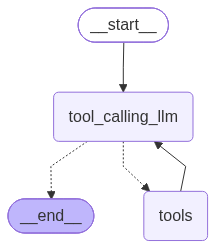

In [37]:
# Stategraph
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

#Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
response=graph. invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (call_117022)
 Call ID: call_117022
  Args:
    topic: news
    query: artificial intelligence latest news 2026
  multiply (call_117023)
 Call ID: call_117023
  Args:
    b: 10
    a: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "artificial intelligence latest news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.usnews.com/news/national-news/articles/2026-09-15/is-ai-escaping-human-control-where-musk-altman-and-trump-stand-on-the-risk", "title": "Is AI Escaping Human Control? Where Sanders, Trump and Others Stand on the Risk", "content": "US President Donald Trump (C) and Open AI CEO Sam Altman (L) react during a working lun

### Adding Memory in AGentic Graph

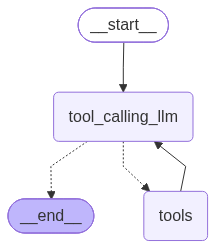

In [41]:
# Stategraph
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

#Compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Krish"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='ecb77ee9-dcdc-4ea2-9b03-a640d3b95026'),
  AIMessage(content=[{'type': 'text', 'text': "Hello Krish! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'El4KXAERTTIP8iP7n62CpQe0UCHlk3wIIMx8f3aq1Vku9a9NNxDE/LqtGzWqpcc/U9ldHz8yj9a7+HmHZRMfM+Mv0T4iiKnNiRJrKNh1iYPKAnYLYAtj/YnVn9B8wPTO'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a7b2-e257-7953-b0c5-1efc2899c9d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1561, 'output_tokens': 18, 'total_tokens': 1579, 'input_token_details': {'cache_read': 0}})]}

In [43]:
response['messages'][-1].content

[{'type': 'text',
  'text': "Hello Krish! It's nice to meet you. How can I help you today?",
  'extras': {'signature': 'El4KXAERTTIP8iP7n62CpQe0UCHlk3wIIMx8f3aq1Vku9a9NNxDE/LqtGzWqpcc/U9ldHz8yj9a7+HmHZRMfM+Mv0T4iiKnNiRJrKNh1iYPKAnYLYAtj/YnVn9B8wPTO'}}]

In [47]:
response=graph.invoke({"messages":"Hey do you remember me?"},config=config)

response["messages"][-1].content

[{'type': 'text',
  'text': "Yes, I do! You're Krish. 😊",
  'extras': {'signature': 'El4KXAERTTIP5QnoD0/4gBzHf7dWturdb3uZec2MFhlYte/FyOhMcRS0B4HMF5IfNfqLVcVPN+TrgQexzcooJ2bgA4wbeZa6SsBwM5MW5hxVxmxcZfRBO6oGnmXHzabU'}}]

### STreaming

In [48]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [49]:
## NOde Definition
def superbot(State:State):
    return {"messages":[llm.invoke(State['messages'])]}

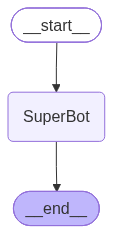

In [50]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot", superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [51]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='fa34bd2a-624c-40c3-8500-10eda7a590c0'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Krish! Nice to meet you. \n\nCricket is a fantastic sport! Who is your favorite team or player? (I'm a big fan of the game myself, though as an AI, I only get to watch it through data!)", 'extras': {'signature': 'El4KXAERTTIP3vjWeBXxuqe8HScJfYeTocoiAaAQHus9ZwwHB1fYU28qSZtb5Vnws+ONE2smQMYmL98zcdCJaQuvLpuchKKIYK87DcjwFndfHjxbRwm1eiLaR4W6GhRb'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a98c-b541-7d80-ac0b-dd831acc2587-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 50, 'total_tokens': 61, 'input_token_details': {'cache_read': 0}})]}

### Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

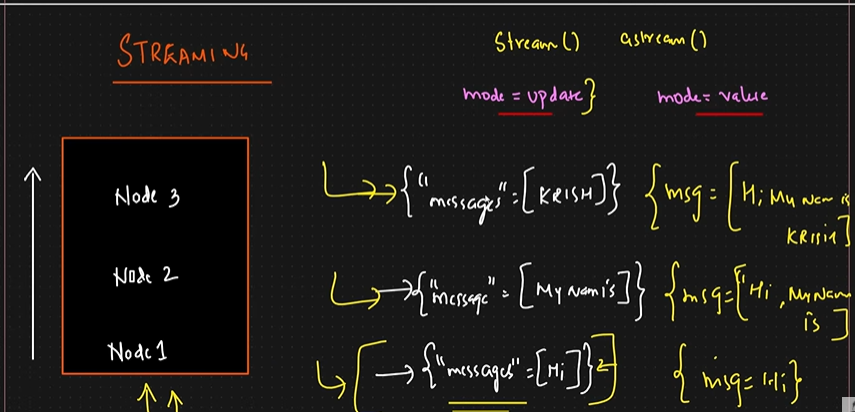

In [52]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi Krish! Nice to meet you. \n\nCricket is a fantastic sport! Who is your favorite team or player? (I'm a big fan of the game myself—well, virtually speaking!)", 'extras': {'signature': 'El4KXAERTTIP2x6RyOawp2uFW9Qm5pE8KgapgkVnXpdfDbbtMdRx1Wf0kTTpvjcQGv2+9mlUS9DpgT+Lb9c+Gu/KrnEUx8kUnVKQICizNPsxnCRFzc8DtFFV24DMBQoz'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a993-0903-7b61-b0bb-d11384684fff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 41, 'total_tokens': 52, 'input_token_details': {'cache_read': 0}})]}}


In [54]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f34f9def-2776-4573-ae00-86ee7689f560'), AIMessage(content=[{'type': 'text', 'text': "Hi Krish! Nice to meet you. \n\nCricket is a fantastic sport! Who is your favorite team or player? (I'm a big fan of the game myself—well, virtually speaking!)", 'extras': {'signature': 'El4KXAERTTIP2x6RyOawp2uFW9Qm5pE8KgapgkVnXpdfDbbtMdRx1Wf0kTTpvjcQGv2+9mlUS9DpgT+Lb9c+Gu/KrnEUx8kUnVKQICizNPsxnCRFzc8DtFFV24DMBQoz'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a993-0903-7b61-b0bb-d11384684fff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 41, 'total_tokens': 52, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_m

In [55]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi Krish! Nice to meet you. \n\nCricket is a fantastic sport! Who is your favorite team or player? (I'm a big fan of the game myself, though as an AI, I only get to watch from the sidelines!)", 'extras': {'signature': 'El4KXAERTTIPGvDqhYGerBcs9nKLx5L/2KIgUOdMl0uIuzxEoLxmXUML0+t9XXthNGjGaA2h+TLfElmSElXTzilbUmi4cFan/JslxjxJ8rGgphcDixv7mYRKr1lDh3wn'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a994-b649-7352-8622-6bd40a9197cf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 50, 'total_tokens': 61, 'input_token_details': {'cache_read': 0}})]}}


In [56]:
for chunk in graph_builder.stream({'messages':"I also like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='aeb73780-ad2d-40b9-8795-76a1cd350bce'), AIMessage(content=[{'type': 'text', 'text': "Hi Krish! Nice to meet you. \n\nCricket is a fantastic sport! Who is your favorite team or player? (I'm a big fan of the game myself, though as an AI, I only get to watch from the sidelines!)", 'extras': {'signature': 'El4KXAERTTIPGvDqhYGerBcs9nKLx5L/2KIgUOdMl0uIuzxEoLxmXUML0+t9XXthNGjGaA2h+TLfElmSElXTzilbUmi4cFan/JslxjxJ8rGgphcDixv7mYRKr1lDh3wn'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0a994-b649-7352-8622-6bd40a9197cf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 50, 'total_tokens': 61, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='I also like football', additional_kwargs=

In [58]:
from distro import version
config = {"configurable": {"thread_id": "5"}}

from pprint import pprint
async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config, version = "v2"):
    pprint(event)

{'data': {'input': {'messages': ['Hi My name is Krish and I like to play '
                                 'cricket']}},
 'event': 'on_chain_start',
 'metadata': {'ls_integration': 'langgraph', 'thread_id': '5'},
 'name': 'LangGraph',
 'parent_ids': [],
 'run_id': '01a0a9ae-9cc6-7f13-ad32-7b47b28c9f94',
 'tags': []}
{'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='ecf7751a-817a-4939-a160-399433499565'),
                                 AIMessage(content=[{'type': 'text', 'text': 'Hi Krish! Nice to meet you. \n\nCricket is a fantastic game! Are you more of a batsman, bowler, or all-rounder? And who is your favorite cricketer or team?', 'index': 0, 'extras': {'signature': 'El4KXAERTTIPtqL4JMWr5PvQqnRWgRP+lSbv2nBVIzjECQdnGHFP6UXQy0wwR5YiP2YdFbcodBJGjjZUv3R/H49CS34B0SY6eJ8vDgZFGU4xiGhc6PY8UvWYJEn/aN8h'}}], additional_kwargs={}, response_metadata={'safety_ratings': [], 'finish_reason': 'S